# Clase 02 — Demostración: tokens, contexto e inferencia

**Dominio independiente:** Generador de Reportes    
**Propósito:** mostrar un método breve para comparar configuraciones.

## Resultado observable

Al terminar, el grupo habrá visto cómo:

1. tokenizar y comparar dos frases;
2. interpretar candidatos para el siguiente token;
3. componer un contexto mínimo;
4. ejecutar la misma pregunta con tres temperaturas;
5. registrar tokens, latencia y respuesta;
6. justificar una configuración inicial.

In [ ]:
# 0. Preparación del entorno (ejecutar antes de la clase)
%pip install -q openai tiktoken pandas matplotlib ollama

import math
import os
import time
from getpass import getpass

import matplotlib.pyplot as plt
import pandas as pd
import tiktoken
from openai import OpenAI

pd.set_option("display.max_colwidth", 100)
print("Entorno preparado.")

Entorno preparado.


## 1. Tokenizar y comparar

- Un token es la unidad que procesa el modelo; no equivale necesariamente a una palabra.
- El tokenizador convierte fragmentos de texto en identificadores numéricos.
- Idiomas, tildes, signos, espacios y palabras poco frecuentes pueden cambiar el conteo.
- No conviene estimar costos contando palabras: se debe usar el tokenizador del modelo o la métrica que reporta el propio modelo al responder.
- **Cada modelo tiene su propio tokenizador.** La celda siguiente usa `tiktoken`, que corresponde a los modelos de OpenAI, únicamente como referencia rápida y local. El conteo válido para el modelo que se ejecutará más adelante aparece en la tabla de resultados del paso 5, en la columna `tokens_entrada`.

In [ ]:
# Paso 1 y 2: tokenizar dos frases y comparar conteos
# Referencia local con el tokenizador de OpenAI; el conteo del modelo local se verifica en el paso 5.
encoding = tiktoken.get_encoding("o200k_base")

frases = {
    "ES": "Hablaremos de los modelos de lenguaje en la generación de reportes.",
    "EN": "We will discuss language models in report generation.",
}

filas_tokens = []
for idioma, texto in frases.items():
    ids = encoding.encode(texto)
    piezas = [encoding.decode([token_id]) for token_id in ids]
    filas_tokens.append({
        "idioma": idioma,
        "texto": texto,
        "palabras_aprox": len(texto.split()),
        "tokens": len(ids),
        "piezas": piezas,
        "ids": ids,
    })

comparacion_tokens = pd.DataFrame(filas_tokens)
display(comparacion_tokens[["idioma", "texto", "palabras_aprox", "tokens", "piezas"]])

,idioma,texto,palabras_aprox,tokens,piezas
0,ES,Hablaremos de los modelos de lenguaje en la generación de reportes.,11,15,"[H, abl, aremos, de, los, modelos, de, lenguaje, en, la, generación, de, report, es, .]"
1,EN,We will discuss language models in report generation.,8,9,"[We, will, discuss, language, models, in, report, generation, .]"


## 2. Candidatos del siguiente token

1. El modelo no entrega primero una oración terminada: calcula una puntuación para muchos tokens candidatos.
2. `softmax` convierte esas puntuaciones en una distribución de probabilidad.
3. La temperatura modifica la forma de esa distribución:
   - temperatura baja: concentra la probabilidad en los candidatos principales;
   - temperatura alta: aplana la distribución y permite más variedad.
4. Una temperatura mayor **no agrega conocimiento ni mejora la veracidad**.
5. `top_p` trabaja después sobre las probabilidades y conserva el grupo mínimo de candidatos cuya suma alcanza el umbral.

temperatura,0.2,0.7,1.2
candidato,,,
Agua,0.0 %,1.9 %,6.3 %
Capuchino,97.0 %,66.1 %,50.8 %
Chocolate,2.9 %,24.3 %,28.3 %
Granizado de Café,0.1 %,7.8 %,14.6 %


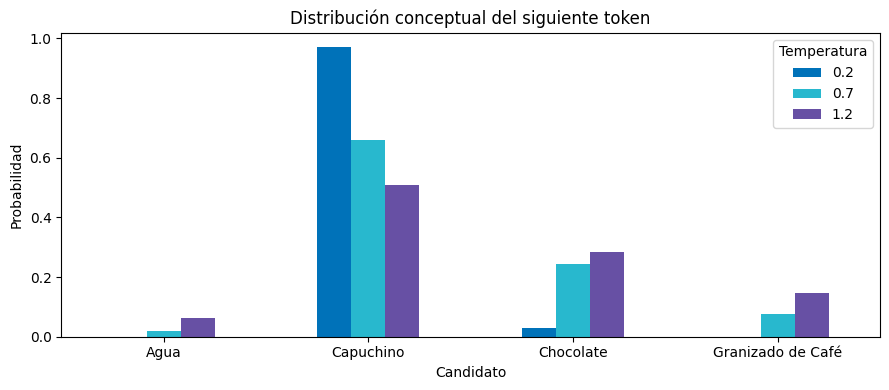

In [ ]:
# Paso 3: visualizar candidatos y el efecto conceptual de la temperatura
### Quiero saber la bebida más vendida en bogotá
candidatos = ["Capuchino", "Chocolate", "Granizado de Café", "Agua"]
logits = [3.2, 2.5, 1.7, 0.7]

def softmax_con_temperatura(valores, temperatura):
    temperatura_segura = max(temperatura, 0.01)
    escalados = [valor / temperatura_segura for valor in valores]
    maximo = max(escalados)
    exponentes = [math.exp(valor - maximo) for valor in escalados]
    total = sum(exponentes)
    return [valor / total for valor in exponentes]

resultados_probabilidad = []
for temperatura in [0.2, 0.7, 1.2]:
    probabilidades = softmax_con_temperatura(logits, temperatura)
    for candidato, probabilidad in zip(candidatos, probabilidades):
        resultados_probabilidad.append({
            "temperatura": temperatura,
            "candidato": candidato,
            "probabilidad": probabilidad,
        })

probabilidades_df = pd.DataFrame(resultados_probabilidad)
pivote = probabilidades_df.pivot(index="candidato", columns="temperatura", values="probabilidad")
display((pivote * 100).round(1).astype(str) + " %")

pivote.plot(kind="bar", figsize=(9, 4), color=["#0072b9", "#28b8ce", "#6750a4"])
plt.title("Distribución conceptual del siguiente token")
plt.ylabel("Probabilidad")
plt.xlabel("Candidato")
plt.xticks(rotation=0)
plt.legend(title="Temperatura")
plt.tight_layout()
plt.show()

## 3. Construir un contexto mínimo

- El contexto no es solamente la pregunta. Incluye instrucción del sistema, datos disponibles, historial si existe y mensaje actual.
- Todo compite por la ventana de contexto y deja un espacio para la respuesta.
- Agregar información irrelevante aumenta tokens y puede distraer al modelo; “más contexto” no significa automáticamente “mejor contexto”.
- El modelo no debe inventar existencias. Si el dato no aparece, la instrucción le exige reconocerlo.
- Este ejercicio aún no es RAG: los cuatro datos se escriben directamente para aislar el efecto de los parámetros.

**Pregunta antes de ejecutar:** ¿qué debería responder si se consulta por pizza?  
**Respuesta esperada:** debe indicar que no existe información suficiente, en lugar de inventar disponibilidad.

In [ ]:
# Paso 4: contexto mínimo, una pregunta y conteo previo
instruccion = """Eres el asistente de generación de reportes para una Cafetería.
Responde únicamente con los datos de las ventas.
Si falta información, dilo claramente. Responde en máximo 45 palabras."""

ventas = """VENTAS
- Capuchino: 8 unidades.
- Chocolate: 3 unidades.
- Agua: 2 unidades."""

pregunta = "Quiero saber la bebida más rica"

messages = [
    {"role": "system", "content": f"{ventas,instruccion}"},
    {"role": "user", "content": f"PREGUNTA: {pregunta}"},
]

texto_contexto = "\n".join(mensaje["content"] for mensaje in messages)
tokens_contexto_estimados = len(encoding.encode(texto_contexto))

print(texto_contexto)
print(f"\nEstimación de referencia (tokenizador de OpenAI): {tokens_contexto_estimados} tokens")
print("El conteo real del modelo local aparecerá en la columna tokens_entrada del paso 5.")

('VENTAS\n- Capuchino: 8 unidades.\n- Chocolate: 3 unidades.\n- Agua: 2 unidades.', 'Eres el asistente de generación de reportes para una Cafetería.\nResponde únicamente con los datos de las ventas.\nSi falta información, dilo claramente. Responde en máximo 45 palabras.')
PREGUNTA: Quiero saber la bebida más rica

Estimación de referencia (tokenizador de OpenAI): 85 tokens
El conteo real del modelo local aparecerá en la columna tokens_entrada del paso 5.


## 4. Conectar el modelo

- El nombre del modelo, el servidor y los parámetros forman parte de la configuración reproducible.
- Al ejecutar el modelo localmente no hay costo por token, pero sí un costo real en memoria de GPU y en tiempo.
- Ollama reporta los tokens reales de entrada y salida junto con los tiempos de carga y generación. Ese dato es preferible a cualquier estimación local.
- El tokenizador de este modelo no es el de OpenAI, por lo que el conteo diferirá del calculado con `tiktoken`.

In [ ]:
!apt-get install -y zstd
!zstd --version

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newly installed, 0 to remove and 57 not upgraded.
*** zstd command line interface 64-bits v1.4.8, by Yann Collet ***


In [ ]:
# Instalar Ollama en la sesión de Colab
!sudo apt-get install -y -q pciutils
!curl -fsSL https://ollama.com/install.sh | sh

# La instalación debe reportar "NVIDIA GPU installed". Si no aparece, revise el entorno de ejecución.
!nvidia-smi --query-gpu=name,memory.total --format=csv

Reading package lists...
Building dependency tree...
Reading state information...
pciutils is already the newest version (1:3.7.0-6).
0 upgraded, 0 newly installed, 0 to remove and 57 not upgraded.
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
name, memory.total [MiB]
Tesla T4, 15360 MiB


In [ ]:
import subprocess
import time
import ollama

In [ ]:
# Iniciar el servidor local y descargar el modelo
# Verifique el nombre en https://ollama.com/library antes de clase.
MODEL_NAME = "gemma4:e2b"

subprocess.Popen(["ollama", "serve"])
time.sleep(10)

!ollama pull {MODEL_NAME}

In [ ]:
# Respuesta de prueba: carga el modelo en memoria y confirma que responde.
prueba = ollama.chat(
    model=MODEL_NAME,
    messages=messages,
    think=False,
    options={"temperature": 0.2, "num_predict": 300},
)
print(prueba["message"]["content"])
print("thinking:", prueba["message"].get("thinking"))

Las ventas registradas son: Capuchino: 8 unidades, Chocolate: 3 unidades, Agua: 2 unidades. No se especifica cuál es la bebida más rica.
thinking: None


In [ ]:
# El modelo debe aparecer con PROCESSOR = 100% GPU.
!ollama ps

NAME          ID              SIZE      PROCESSOR    CONTEXT    UNTIL              
gemma4:e2b    7fbdbf8f5e45    1.7 GB    100% GPU     4096       4 minutes from now    


## 5. Ejecutar tres configuraciones

Se conserva constante:

- el modelo;
- la instrucción;
- el menú;
- la pregunta;
- `top_p = 1.0`;
- el límite de salida.

Solo cambia la temperatura: `0.0`, `0.7` y `1.2`

- Este control de variables permite atribuir las diferencias observadas principalmente a la temperatura.
- Una sola ejecución por configuración sirve para una demostración corta, pero no basta para afirmar estabilidad. En una evaluación formal habría que repetir cada condición.
- La latencia depende de la GPU asignada por Colab y del tamaño del modelo. No se debe interpretar una diferencia pequeña como una propiedad absoluta de la temperatura.
- Los tokens de salida pueden variar porque la formulación y la longitud de cada respuesta cambian.
- La columna `carga_s` muestra el tiempo de carga del modelo en memoria. Solo debe ser alto en la primera ejecución; si aparece alto en todas, el modelo se está descargando de la GPU entre llamadas.

In [ ]:
# Paso 5 y 6: generar con tres temperaturas y registrar tokens + latencia
NANOSEGUNDOS = 1_000_000_000

def ejecutar_prueba(temperatura, top_p=1.0, num_predict=500):
    inicio = time.perf_counter()
    respuesta = ollama.chat(
        model=MODEL_NAME,
        messages=messages,
        options={
            "temperature": temperatura,
            "top_p": top_p,
            "num_predict": num_predict,
        },
    )
    latencia = time.perf_counter() - inicio

    tokens_entrada = respuesta.get("prompt_eval_count")
    tokens_salida = respuesta.get("eval_count")
    carga = respuesta.get("load_duration", 0) / NANOSEGUNDOS

    return {
        "temperatura": temperatura,
        "top_p": top_p,
        "num_predict": num_predict,
        "tokens_entrada": tokens_entrada,
        "tokens_salida": tokens_salida,
        "tokens_total": (tokens_entrada or 0) + (tokens_salida or 0),
        "latencia_s": round(latencia, 2),
        "carga_s": round(carga, 2),
        "respuesta": respuesta["message"]["content"].strip(),
    }

resultados = []
for temperatura in [0.8, 1.7, 2.2]:
    print(f"Ejecutando temperatura={temperatura}...")
    resultados.append(ejecutar_prueba(temperatura=temperatura))

resultados_df = pd.DataFrame(resultados)
display(resultados_df)

print(
    f"Tokens de entrada estimados con tiktoken: {tokens_contexto_estimados} | "
    f"reportados por {MODEL_NAME}: {resultados_df['tokens_entrada'].iloc[0]}"
)

Ejecutando temperatura=0.8...
Ejecutando temperatura=1.7...
Ejecutando temperatura=2.2...


,temperatura,top_p,num_predict,tokens_entrada,tokens_salida,tokens_total,latencia_s,carga_s,respuesta
0,0.8,1.0,500,100,397,497,4.68,0.0,Solo puedo proporcionarte los datos de las ventas. Las ventas registradas son: Capuchino: 8 unid...
1,1.7,1.0,500,100,460,560,5.38,0.0,"La información proporcionada son las unidades vendidas de cada bebida (Capuchino: 8, Chocolate: ..."
2,2.2,1.0,500,100,434,534,5.06,0.0,"Según los datos de venta, el Capuchino fue el más vendido con 8 unidades. El Chocolate se vendie..."


Tokens de entrada estimados con tiktoken: 85 | reportados por gemma4:e2b: 100


In [ ]:
for r in resultados:
    print(r["temperatura"], "->", repr(r["respuesta"])[:300])

0.8 -> 'Solo puedo proporcionarte los datos de las ventas. Las ventas registradas son: Capuchino: 8 unidades, Chocolate: 3 unidades y Agua: 2 unidades. No tengo información sobre qué bebida es la más rica.'
1.7 -> 'La información proporcionada son las unidades vendidas de cada bebida (Capuchino: 8, Chocolate: 3 y Agua: 2). No hay datos sobre la calidad o el sabor para determinar cuál es la bebida más rica.'
2.2 -> 'Según los datos de venta, el Capuchino fue el más vendido con 8 unidades. El Chocolate se vendieron 3 unidades y el Agua 2 unidades. No tengo datos sobre las preferencias gustativas de los clientes.'


## 5.1 Lectura guiada de la tabla

1. **Validez factual:** descarte primero cualquier respuesta que contradiga el menú o invente información.
2. **Cumplimiento:** compruebe que responde la pregunta y respeta el límite de extensión.
3. **Estabilidad:** compare cuánto cambia la formulación entre temperaturas.
4. **Eficiencia:** observe tokens de salida y latencia, sin sobrerreaccionar a diferencias pequeñas.
5. **Adecuación al caso:** para existencias y horarios, la diversidad suele aportar menos valor que la consistencia.
6. **Tokenizador:** compare la estimación de `tiktoken` con los `tokens_entrada` reportados por el modelo. La diferencia demuestra que un conteo tomado de otro tokenizador solo sirve como aproximación.

In [ ]:
# Resumen compacto para proyectar y copiar a la bitácora
resumen = resultados_df[
    ["temperatura", "tokens_entrada", "tokens_salida", "latencia_s", "carga_s", "respuesta"]
].copy()
resumen["cumple_datos"] = "REVISAR"
resumen["decision"] = "CONSERVAR / DESCARTAR"

display(resumen)

print("\nDECISIÓN MODELO PARA LA BITÁCORA")
print("Conservamos temperatura = ____ porque ________________________________.")
print("Observamos como limitación ___________________________________________.")
print("En la siguiente prueba cambiaremos únicamente ________________________.")

,temperatura,tokens_entrada,tokens_salida,latencia_s,carga_s,respuesta,cumple_datos,decision
0,0.8,100,397,4.68,0.0,Solo puedo proporcionarte los datos de las ventas. Las ventas registradas son: Capuchino: 8 unid...,REVISAR,CONSERVAR / DESCARTAR
1,1.7,100,460,5.38,0.0,"La información proporcionada son las unidades vendidas de cada bebida (Capuchino: 8, Chocolate: ...",REVISAR,CONSERVAR / DESCARTAR
2,2.2,100,434,5.06,0.0,"Según los datos de venta, el Capuchino fue el más vendido con 8 unidades. El Chocolate se vendie...",REVISAR,CONSERVAR / DESCARTAR



DECISIÓN MODELO PARA LA BITÁCORA
Conservamos temperatura = ____ porque ________________________________.
Observamos como limitación ___________________________________________.
En la siguiente prueba cambiaremos únicamente ________________________.


## 6. Puente al laboratorio

Cada equipo repite el método con su propio proyecto:

1. selecciona una pregunta normal y una ambigua;
2. conserva el mismo modelo, contexto y pregunta;
3. ejecuta temperaturas `0.0`, `0.7` y `1.2`;
4. registra tokens, latencia y respuesta;
5. marca cumplimiento y errores;
6. conserva una configuración inicial justificada.

### Evidencia mínima

- notebook ejecutado;
- tabla comparativa;
- prompt y contexto usados;
- decisión en la bitácora;
- un error o limitación reconocido.